# **IBL - Processed Behavioral Data**

This tutorial shows how to access data from [DANDI:001757](https://dandiarchive.org/dandiset/001757/draft) for the IBL mesoscope dataset

## Study Overview

This project aims to generate a rich, large-scale dataset capturing the activity of defined neural populations during the IBL decision-making task, using a 2-photon random access mesoscope. By imaging calcium activity in excitatory neurons across the dorsal cortex of transgenic mice, we seek to characterize how population-level neural activity encodes key task variables such as stimulus, choice, and bias context. Imaging functionally connected regions simultaneously allows us to investigate interregional interactions and trial-to-trial dynamics, while repeated recordings across days will help assess the stability of these neural representations over time and their relationship to expert performance.

## Contents

1. [Setup and Data Access](#setup)
2. [Session and Subject Metadata](#metadata)
3. [Epochs (Task vs Passive)](#epochs)
4. [Trials](#trials)
5. [Pupil](#pupil)
6. [Lick Times](#lick-times)
8. [ROI Motion Energy](#motion-energy)
9. [Wheel](#wheel)

---

# 1. Setup and Data Access <a id="setup"></a>

## Import Required Libraries

In [ ]:
import matplotlib.pyplot as plt

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

---

# 2. Session and Subject Metadata <a id="metadata"></a>

In [ ]:
from .load_nwb_utils import *

# Load session data
dandiset_id = "001757"
subject_id = "SP061"  # Example subject
session_id = "5ce2e17e-8471-42d4-8a16-21949710b328"  # EID for the session
# session_id = "42d7e11e-3185-4a79-a6ad-bbaf47366db2"  # EID for the session


# Choose data source (DANDI streaming or local)
USE_DANDI = True  # Set to False to use local files

if USE_DANDI:
    nwbfile, io = load_nwb_from_dandi(dandiset_id, subject_id, session_id, description="processed")
else:
    # TODO Specify your local directory path
    local_directory = f"E:/IBL-mesoscope-nwbfiles/full/"
    nwbfile, io = load_nwb_local(local_directory, subject_id, session_id, description="processed")

print("=== SESSION INFORMATION ===")
print(f"Experiment description:\n {nwbfile.experiment_description}")
print(f"Session description:\n {nwbfile.session_description}")
print(f"Session start time:\n {nwbfile.session_start_time}")

=== SESSION INFORMATION ===
Experiment description:
 This experiment aims to capture the activity of defined neural populations during the IBL decision-making task, using a 2-photon random access mesoscope. By imaging calcium activity in excitatory neurons across the dorsal cortex of transgenic mice, we seek to characterize how population-level neural activity encodes key task variables such as stimulus, choice, and bias context.
Session description:
 The task protocol(s) performed in this experimental session:
1. Cued biased choice world — a custom variant of the biased choice world task with added visual cues. The mouse performs a decision-making task: a Gabor patch appears on the left or right of the screen, and the mouse turns a steering wheel to bring it to the center. Correct responses are rewarded with water. Stimulus probability alternates between 80/20 and 20/80 blocks. All contrast levels are used (100%, 25%, 12.5%, 6.25%, 0%).
2. Passive video presentation — typically a Perl

In [3]:
print("=== SUBJECT INFORMATION ===")
print(f"ID: {nwbfile.subject.subject_id}")
print(f"Age: {nwbfile.subject.age}")
print(f"Strain: {nwbfile.subject.species}")
print(f"Genotype: {nwbfile.subject.genotype}")
print(f"Sex: {nwbfile.subject.sex}")

=== SUBJECT INFORMATION ===
ID: SP061
Age: None
Strain: Mus musculus
Genotype: None
Sex: F


---

# 3. Epochs <a id="epochs"></a>

In [4]:
nwbfile.epochs

,start_time,stop_time,protocol_type,protocol_description,task_settings
id,,,,,
0,0.788921,3206.718142,active,"Cued biased choice world — a custom variant of the biased choice world task with added visual cues. The mouse performs a decision-making task: a Gabor patch appears on the left or right of the screen, and the mouse turns a steering wheel to bring it to the center. Correct responses are rewarded with water. Stimulus probability alternates between 80/20 and 20/80 blocks. All contrast levels are used (100%, 25%, 12.5%, 6.25%, 0%).","{'ADAPTIVE_REWARD': False, 'ALYX_LAB': 'cortexlab', 'ALYX_USER': 'carolina.quadrado', 'AUTOMATIC_CALIBRATION': True, 'BLOCK_INIT_5050': True, 'BLOCK_LEN_FACTOR': 60, 'BLOCK_LEN_MAX': 100, 'BLOCK_LEN_MIN': 20, 'BLOCK_PROBABILITY_SET': [0.2, 0.8], 'BONSAI_EDITOR': False, 'CALIBRATION_VALUE': 0.067, 'CONTRAST_SET': [1.0, 0.25, 0.125, 0.0625, 0], 'CONTRAST_SET_PROBABILITY_TYPE': 'uniform', 'DEAD_TIME': 0.5, 'FEEDBACK_CORRECT_DELAY_SECS': 1, 'FEEDBACK_ERROR_DELAY_SECS': 2, 'FEEDBACK_NOGO_DELAY_SECS': 2, 'GO_TONE_AMPLITUDE': 0.0272, 'GO_TONE_DURATION': 0.11, 'GO_TONE_FREQUENCY': 5000, 'GO_TONE_IDX': 2, 'IBLRIG_VERSION': '8.27.0', 'INTERACTIVE_DELAY': 1, 'ITI_DELAY_SECS': 0.5, 'MAIN_SYNC': False, 'NTRIALS': 522, 'NTRIALS_CORRECT': 424, 'POOP_COUNT': 3, 'PROBABILITY_LEFT': 0.5, 'PROCEDURES': ['Imaging'], 'PROJECTS': ['ibl_mesoscope_active'], 'PROJECT_EXTRACTION_VERSION': '0.5.4', 'PYBPOD_PROTOCOL': 'samuel_cuedBiasedChoiceWorld', 'QUIESCENCE_THRESHOLDS': [-2, 2], 'QUIESCENT_PERIOD': 0.2, 'RECORD_AMBIENT_SENSOR_DATA': True, 'RECORD_SOUND': True, 'RESPONSE_WINDOW': 60, 'REWARD_AMOUNT_UL': 1.5, 'REWARD_TYPE': 'Water 10% Sucrose', 'RIG_NAME': '_iblrig_cortexlab_mesoscope', 'SESSION_DELAY_START': 0.0, 'SESSION_END_TIME': '2025-01-28T11:43:25.718142', 'SESSION_NUMBER': 1, 'SESSION_START_TIME': '2025-01-28T10:49:59.788921', 'STIM_ANGLE': 0.0, 'STIM_FREQ': 0.1, 'STIM_GAIN': 4.0, 'STIM_POSITIONS': [-35, 35], 'STIM_REVERSE': False, 'STIM_SIGMA': 7.0, 'STIM_TRANSLATION_Z': 7, 'SUBJECT_NAME': 'SP061', 'SUBJECT_WEIGHT': 21.7, 'SYNC_SQUARE_X': 1.33, 'SYNC_SQUARE_Y': -1.03, 'TOTAL_WATER_DELIVERED': 636.0, 'USE_AUTOMATIC_STOPPING_CRITERIONS': True, 'VERSION': '1.0.0', 'VISUAL_STIMULUS': 'GaborIBLTask/Gabor2D.bonsai', 'WHITE_NOISE_AMPLITUDE': 0.05, 'WHITE_NOISE_DURATION': 0.5, 'WHITE_NOISE_IDX': 3, 'device_bpod': {'BPOD_TTL_TEST_DATE': None, 'BPOD_TTL_TEST_STATUS': None, 'COM_BPOD': 'COM3', 'DISABLE_BEHAVIOR_INPUT_PORTS': [2, 3, 4], 'ROTARY_ENCODER_BPOD_PORT': 'Serial1', 'SOUND_BOARD_BPOD_PORT': 'Serial3'}, 'device_cameras': {}, 'device_frame2ttl': {'COM_F2TTL': 'COM8', 'F2TTL_CALIBRATION_DATE': '2025-01-20', 'F2TTL_DARK_THRESH': -170, 'F2TTL_LIGHT_THRESH': 157}, 'device_microphone': {'BONSAI_WORKFLOW': 'devices\\microphone\\record_mic.bonsai'}, 'device_neurophotometrics': None, 'device_rotary_encoder': {'COM_ROTARY_ENCODER': 'COM4', 'WHEEL_DIAMETER_MM': 62.0}, 'device_scale': {'COM_SCALE': None}, 'device_screen': {'DISPLAY_IDX': 1, 'SCREEN_FREQ_TARGET': 60, 'SCREEN_FREQ_TEST_DATE': None, 'SCREEN_FREQ_TEST_STATUS': None, 'SCREEN_LUX_DATE': None, 'SCREEN_LUX_VALUE': None}, 'device_sound': {'AMP_TYPE': None, 'COM_SOUND': 'COM9', 'OUTPUT': 'harp'}, 'device_valve': {'FREE_REWARD_VOLUME_UL': 1.5, 'WATER_CALIBRATION_DATE': '2025-01-16', 'WATER_CALIBRATION_N': 5, 'WATER_CALIBRATION_OPEN_TIMES': [50.0, 87.5, 125.0, 162.5, 200.0], 'WATER_CALIBRATION_RANGE': [50.0, 200.0], 'WATER_CALIBRATION_WEIGHT_PERDROP': [0.25, 1.2173913043478262, 2.0, 2.9032258064516125, 3.8]}}"
1,3243.955465,3857.793778,passive,Passive video presentation — typically a Perlin noise video (spatio-temporal noise pattern) played to the mouse for retinotopic mapping and visual cortex characterization. No behavioral contingency — the mouse simply views the screen.,"{'ALYX_LAB': 'cortexlab', 'ALYX_USER': 'carolina.quadrado', 'IBLRIG_VERSION': '8.27.0', 'ITI_DELAY_SECS': 1, 'MAIN_SYNC': False, 'NREPEATS': 2, 'NTRIALS': 2, 'NTRIALS_CORRECT': 0, 'POOP_COUNT': 0, 'P

---

# 4. Trials <a id="trials"></a>

The IBL decision-making task uses a Gabor patch stimulus that appears on the left or
right side of the screen. The mouse rotates a steering wheel to move the stimulus toward
the screen center and receives a water reward for correct choices. Stimulus contrast and
side probability vary across trials in a block structure.

Key trial columns:
| Column | Description |
|---|---|
| `start_time` / `stop_time` | Trial start and end times (s) |
| `stim_on_time` | Visual stimulus onset (s) |
| `go_cue_time` | Auditory go cue (s) |
| `response_time` | Wheel movement response registered (s) |
| `feedback_time` | Reward or penalty delivered (s) |
| `choice` | Mouse choice: -1 = right, +1 = left |
| `feedback_type` | 1 = correct/reward, -1 = incorrect/penalty |
| `contrast_left` / `contrast_right` | Stimulus contrast on each side (0-1) |
| `probability_left` | Prior probability of left stimulus in this block |
| `reward_volume` | Water reward volume (uL) |

In [5]:
print("=== INTERVALS MODULE ===\n")
trials = nwbfile.intervals["trials"]
print("-" * 100)
print("Trials Table (first 5 rows):")
display(trials.to_dataframe().head(5))  # Print first 5 rows as example
print("-" * 100)

=== INTERVALS MODULE ===

----------------------------------------------------------------------------------------------------
Trials Table (first 5 rows):


,start_time,stop_time,quiescence_period,gabor_stimulus_onset_time,auditory_cue_time,wheel_movement_onset_time,choice_registration_time,feedback_time,gabor_stimulus_offset_time,gabor_stimulus_contrast,gabor_stimulus_side,mouse_wheel_choice,is_mouse_rewarded,reward_volume_uL,probability_left,block_type,block_index
id,,,,,,,,,,,,,,,,,
0,26.539974,32.715040,0.552550,28.316,27.095,27.747,31.064014,31.078,32.215,6.25,right,counter_clockwise,True,1.5,0.5,unbiased,0
1,32.746440,40.698956,0.686535,38.583,37.521,38.773,39.047513,39.060,40.199,100.00,right,counter_clockwise,True,1.5,0.5,unbiased,0
2,40.741550,45.015042,0.556929,42.882,41.835,42.102,43.360607,43.373,44.515,12.50,left,clockwise,True,1.5,0.5,unbiased,0
3,45.043743,48.681989,0.479683,46.582,45.524,46.792,47.005804,47.018,48.182,12.50,right,counter_clockwise,True,1.5,0.5,unbiased,0
4,48.708485,52.232039,0.464623,50.250,49.174,50.206,50.576933,50.589,51.732,12.50,left,clockwise,True,1.5,0.5,unbiased,0


----------------------------------------------------------------------------------------------------


---

# 5. Pupil Tracking <a id="pupil"></a>

Pupil diameter measurements from video-based eye tracking are stored as `TimeSeries` in the `pupil` processing module. Each camera contributes a raw and a smoothed diameter trace (in pixels).

| Series name | Content |
|---|---|
| `LeftPupilDiameter` | Raw left-camera pupil diameter |
| `LeftPupilDiameterSmoothed` | Temporally smoothed left-camera diameter |
| `RightPupilDiameter` | Raw right-camera pupil diameter |
| `RightPupilDiameterSmoothed` | Temporally smoothed right-camera diameter |

Access example
```python
pupil_module = nwbfile.processing["pupil"]
left_raw = pupil_module["LeftPupilDiameter"]
timestamps = left_raw.timestamps[:]
diameter  = left_raw.data[:]

In [6]:
pupil_module = nwbfile.processing["pupil"]

print("=== PUPIL PROCESSING MODULE ===")
print("-" * 80)
for name, ts in pupil_module.data_interfaces.items():
    print(f"  {name}")
    print(f"    Description: {ts.description}")
    print(f"    Samples: {ts.data.shape[0]}  |  Unit: {ts.unit}")
    print("-" * 80)

=== PUPIL PROCESSING MODULE ===
--------------------------------------------------------------------------------
  LeftPupilDiameter
    Description: Raw pupil diameter estimated from pose tracking keypoints around the pupil boundary. Multiple diameter estimates are computed: vertical (top-bottom distance), horizontal (left-right distance), and circular fits from other keypoint pairs. The final value is the median of these estimates, providing robustness against individual tracking errors.
    Samples: 240066  |  Unit: px
--------------------------------------------------------------------------------
  LeftPupilDiameterSmoothed
    Description: Smoothed pupil diameter. This version has been temporally smoothed and interpolated over frames with missing or low-confidence keypoint detections. Useful for analyses where smooth trajectories are preferred over frame-by-frame accuracy.
    Samples: 240066  |  Unit: px
---------------------------------------------------------------------------

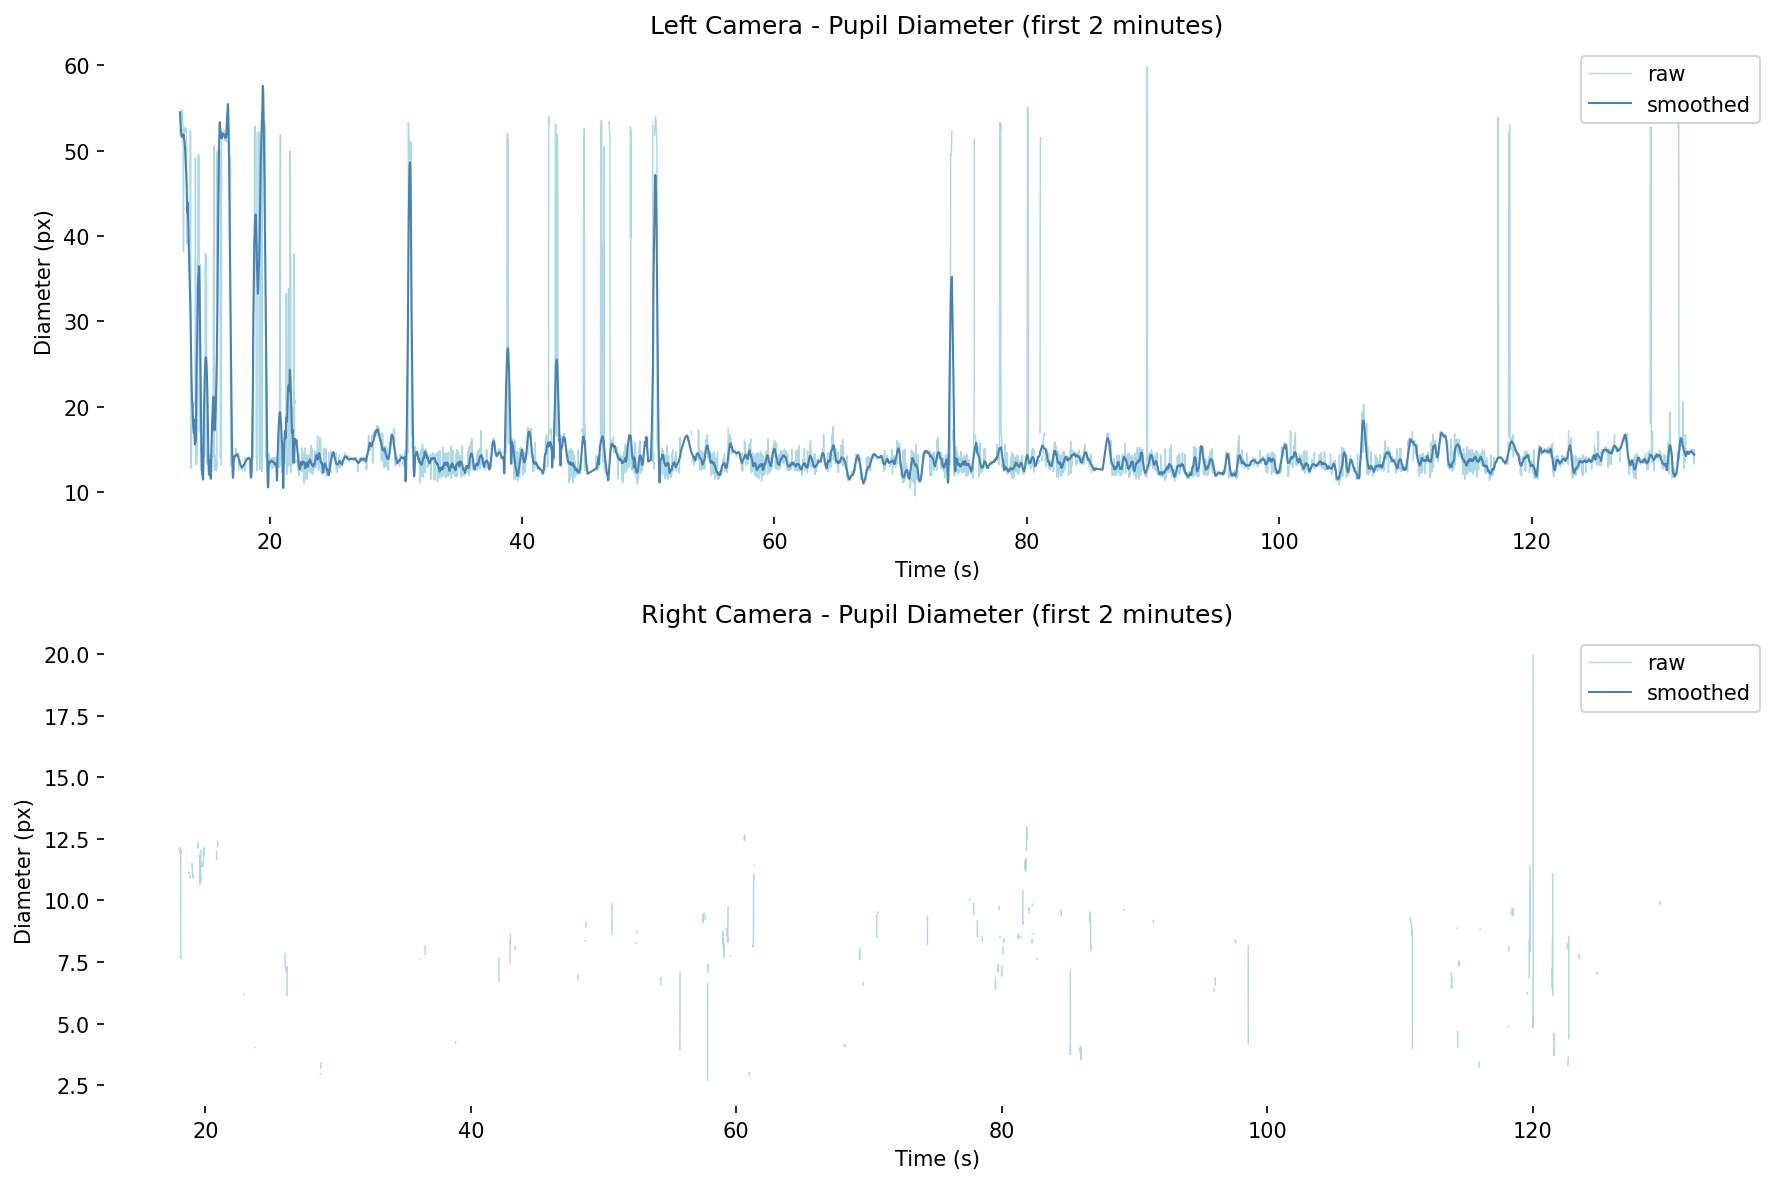

In [7]:
# --- Plot raw and smoothed pupil diameter for left and right cameras ---
cameras = ["Left","Right"] # TODO do not assume there are both cameras
fig, axes = plt.subplots(len(cameras), 1, figsize=(12, 4 * len(cameras)), dpi=150, sharex=False)

for ax, cam in zip(axes, cameras):
    raw_key = f'{cam}PupilDiameter'
    smooth_key = f"{cam}PupilDiameterSmoothed"
    pupil_module = nwbfile.processing['pupil']

    raw_ts = pupil_module[raw_key]
    smooth_ts = pupil_module[smooth_key]

    t = raw_ts.timestamps[:]
    window_mask = (t >= t[0]) & (t <= t[0] + 120.0)
    t_win = t[window_mask]

    ax.plot(t_win, raw_ts.data[window_mask], color='lightblue', linewidth=0.7, label='raw')
    ax.plot(t_win, smooth_ts.data[window_mask], color='steelblue', linewidth=1.0, label='smoothed')
    ax.set_title(f'{cam} Camera - Pupil Diameter (first 2 minutes)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Diameter (px)')
    ax.legend(loc='upper right')
    ax.set_frame_on(False)

plt.tight_layout()
plt.show()

---

# 6. Lick Times <a id="lick-times"></a>

Lick events detected from video-based tongue pose estimation are stored as an `Events` object
in the `lick_times` processing module.

In [8]:
if "lick_times" not in nwbfile.processing:
    print("lick_times module not available for this session — skipping.")
else:
    lick_events = nwbfile.processing["lick_times"]["EventsLickTimes"]

    print("=== LICK TIMES ===")
    print(f"Description: {lick_events.description}\n")
    lick_times = lick_events.timestamps[:]
    print(f"Number of licks     : {len(lick_times)}")
    print(f"Session duration    : {lick_times[-1] - lick_times[0]:.2f} s")
    print(f"Mean lick rate      : {len(lick_times) / (lick_times[-1] - lick_times[0]):.2f} licks/s")

=== LICK TIMES ===
Description: Lick event timestamps detected from tongue pose estimation (Lightning Pose). Detection algorithm: frame-to-frame position changes in tongue landmarks (tongue_end_l_x, tongue_end_l_y, tongue_end_r_x, tongue_end_r_y) are computed, and frames where any coordinate changes by more than std(diff)/4 are marked as lick events. If left and right camera data exist, the licks detected from both cameras are combined.

Number of licks     : 13796
Session duration    : 3978.75 s
Mean lick rate      : 3.47 licks/s


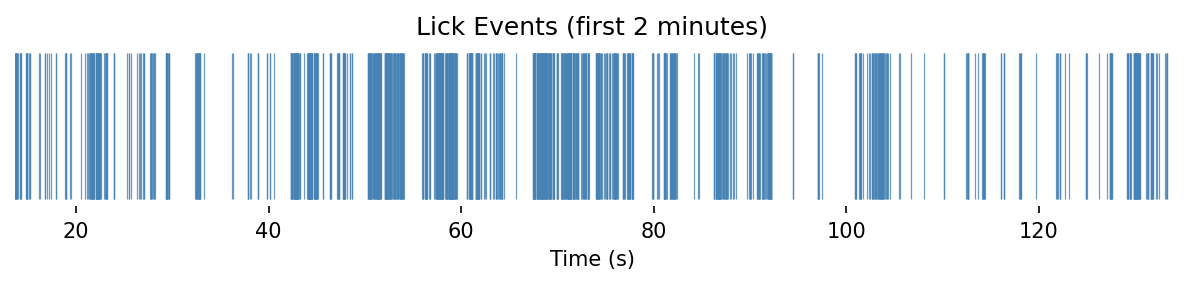

In [9]:
if "lick_times" in nwbfile.processing:
    # Lick raster over a 2-minute window
    window_start = lick_times[0]
    window_end = lick_times[0] + 120.0
    lick_window = lick_times[(lick_times >= window_start) & (lick_times <= window_end)]

    fig, ax = plt.subplots(figsize=(8, 2), dpi=150)
    ax.vlines(lick_window, 0, 1, linewidth=0.6, color="steelblue", alpha=0.8)
    ax.set_xlim(window_start, window_end)
    ax.set_yticks([])
    ax.set_xlabel("Time (s)")
    ax.set_title("Lick Events (first 2 minutes)")
    ax.set_frame_on(False)
    plt.tight_layout()
    plt.show()

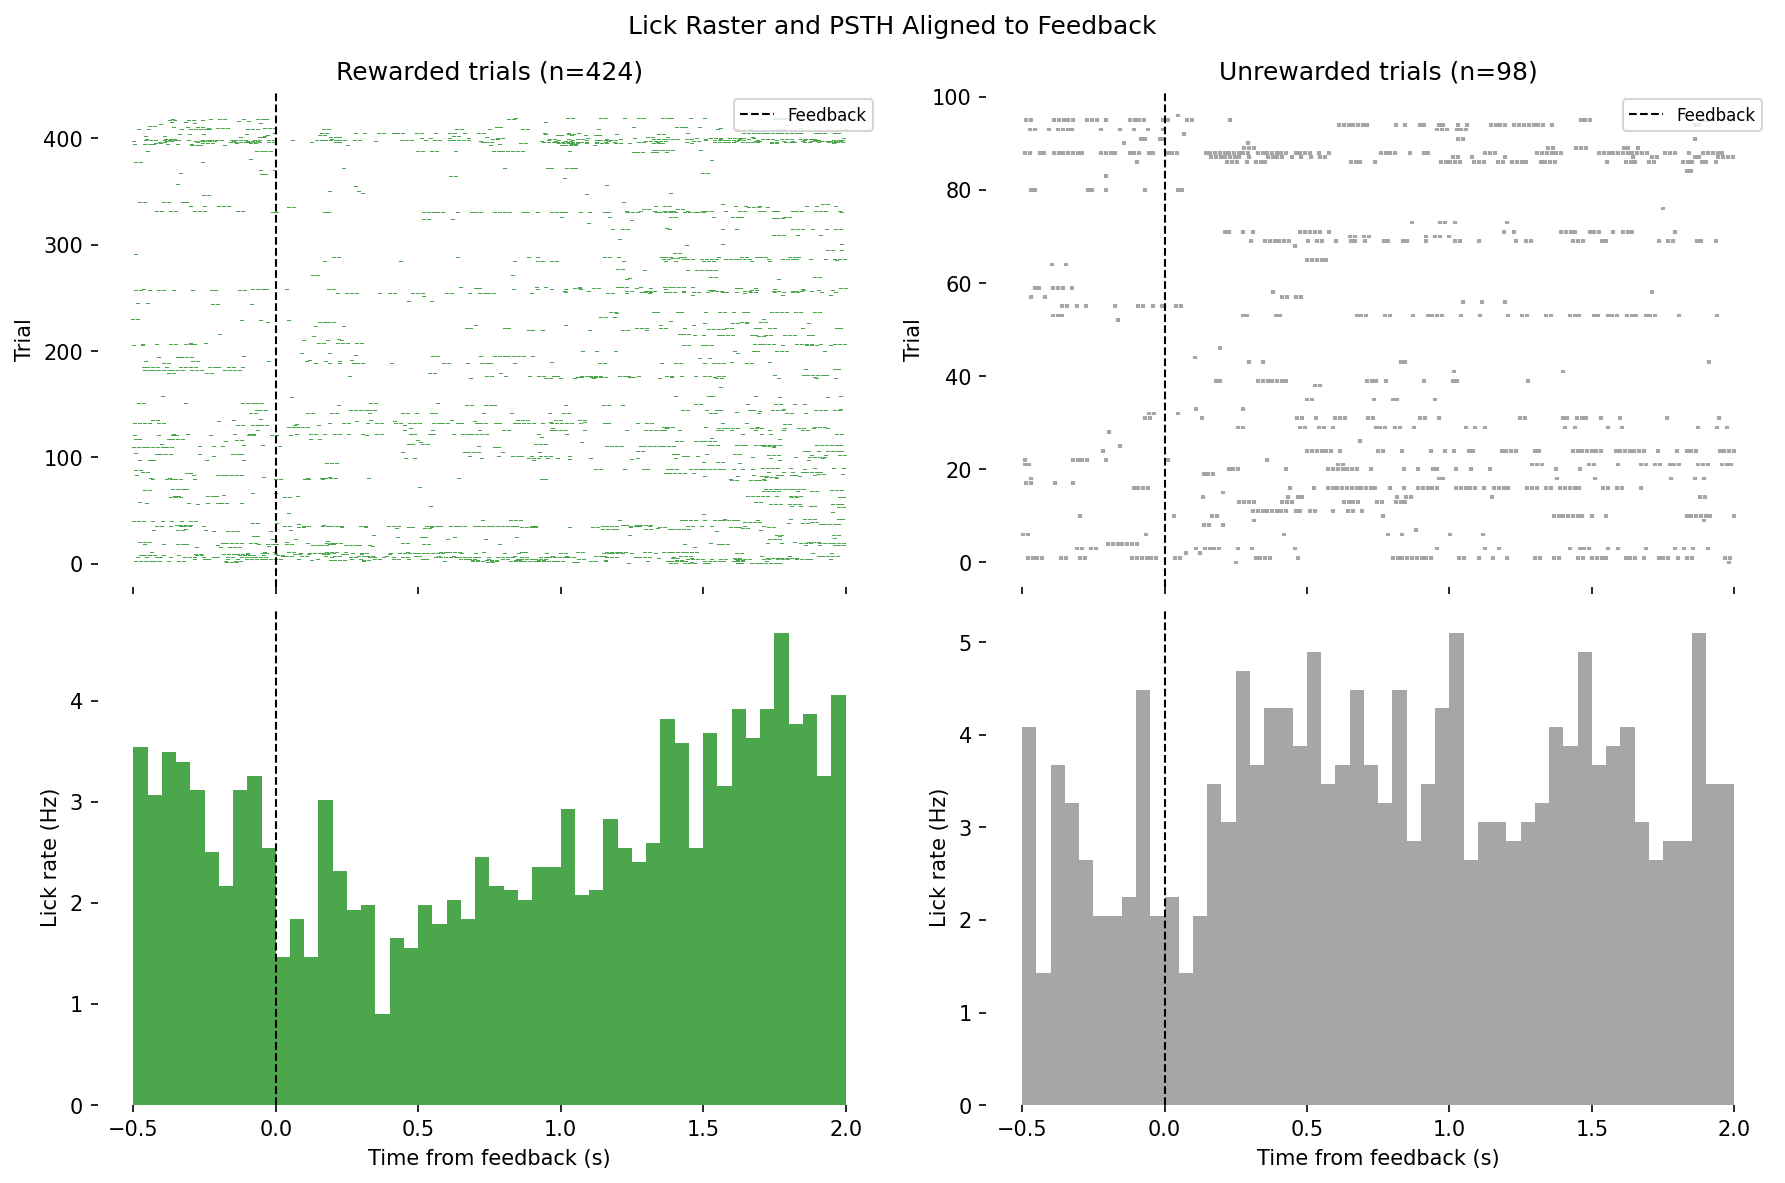

In [10]:
if "lick_times" in nwbfile.processing:
    # Trial-aligned lick raster + PSTH around feedback time
    pre_time = 0.5  # s before feedback
    post_time = 2.0  # s after feedback
    bin_size = 0.05  # 50 ms bins

    feedback_times = nwbfile.trials["feedback_time"][:]
    is_rewarded = nwbfile.trials["is_mouse_rewarded"][:]

    bins = np.arange(-pre_time, post_time + bin_size, bin_size)
    bin_centers = bins[:-1] + bin_size / 2

    raster_rewarded, raster_unrewarded = [], []
    psth_rewarded = np.zeros(len(bins) - 1)
    psth_unrewarded = np.zeros(len(bins) - 1)

    for t_fb, rewarded in zip(feedback_times, is_rewarded):
        rel = lick_times[(lick_times >= t_fb - pre_time) & (lick_times <= t_fb + post_time)] - t_fb
        counts, _ = np.histogram(rel, bins=bins)
        if rewarded:
            raster_rewarded.append(rel)
            psth_rewarded += counts
        else:
            raster_unrewarded.append(rel)
            psth_unrewarded += counts

    n_rew = max(len(raster_rewarded), 1)
    n_unrew = max(len(raster_unrewarded), 1)
    psth_rewarded /= n_rew * bin_size
    psth_unrewarded /= n_unrew * bin_size

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150, sharex=True)

    for col, (raster, psth, label, color) in enumerate(
        [
            (raster_rewarded, psth_rewarded, "Rewarded", "green"),
            (raster_unrewarded, psth_unrewarded, "Unrewarded", "gray"),
        ]
    ):
        for trial_idx, trial_lick_times in enumerate(raster):
            axes[0, col].vlines(trial_lick_times, trial_idx - 0.4, trial_idx + 0.4, linewidth=2, color=color, alpha=0.7)
        axes[0, col].axvline(0, color="black", linewidth=1, linestyle="--", label="Feedback")
        axes[0, col].set_ylabel("Trial")
        axes[0, col].set_title(f"{label} trials (n={len(raster)})")
        axes[0, col].legend(loc="upper right", fontsize=8)
        axes[0, col].set_frame_on(False)

        axes[1, col].bar(bin_centers, psth, width=bin_size, color=color, alpha=0.7, edgecolor="none")
        axes[1, col].axvline(0, color="black", linewidth=1, linestyle="--")
        axes[1, col].set_xlabel("Time from feedback (s)")
        axes[1, col].set_ylabel("Lick rate (Hz)")
        axes[1, col].set_frame_on(False)

    fig.suptitle("Lick Raster and PSTH Aligned to Feedback", fontsize=12)
    plt.tight_layout()
    plt.show()

---

# 7. ROI motion energy <a id="motion-energy"></a>

Motion energy quantifies movement within a fixed region of interest (ROI) in the camera
video. For each frame pair, pixel intensity differences are computed and summed across
the ROI to produce a single scalar value. Higher values indicate more movement within the
ROI. The left and right cameras each provide a separate motion energy trace, useful for
detecting gross body movements and correlating them with neural activity.

In [11]:
print("=== MOTION ENERGY PROCESSING MODULE ===\n")
motion_energy_series = []
for name, proc in nwbfile.processing["motion_energy"].items():
    if "MotionEnergy" not in name:
        continue
    print("-" * 100)
    print(f"Motion Energy Times Series: {name}")
    print(f"   Description: {proc.description}")
    print("-" * 100)
    motion_energy_series.append(name)

=== MOTION ENERGY PROCESSING MODULE ===

----------------------------------------------------------------------------------------------------
Motion Energy Times Series: LeftCameraMotionEnergy
   Description: Motion energy calculated for a region of the left camera video. ROI dimensions: 153 pixels wide, 102 pixels tall, top-left corner at (194, 368).

Calculation: For each frame, pixel intensity differences are computed between frame N and frame N+2 (default offset). The Euclidean norm (L2) of differences is summed across all ROI pixels, then min-max normalized to [0, 1] range. Higher values indicate more movement within the ROI.

CAUTION: Video loading libraries may use different axis conventions. When loading with cv2 in Python, x and y axes are flipped. The region then becomes [368:470, 194:347].
----------------------------------------------------------------------------------------------------
---------------------------------------------------------------------------------------

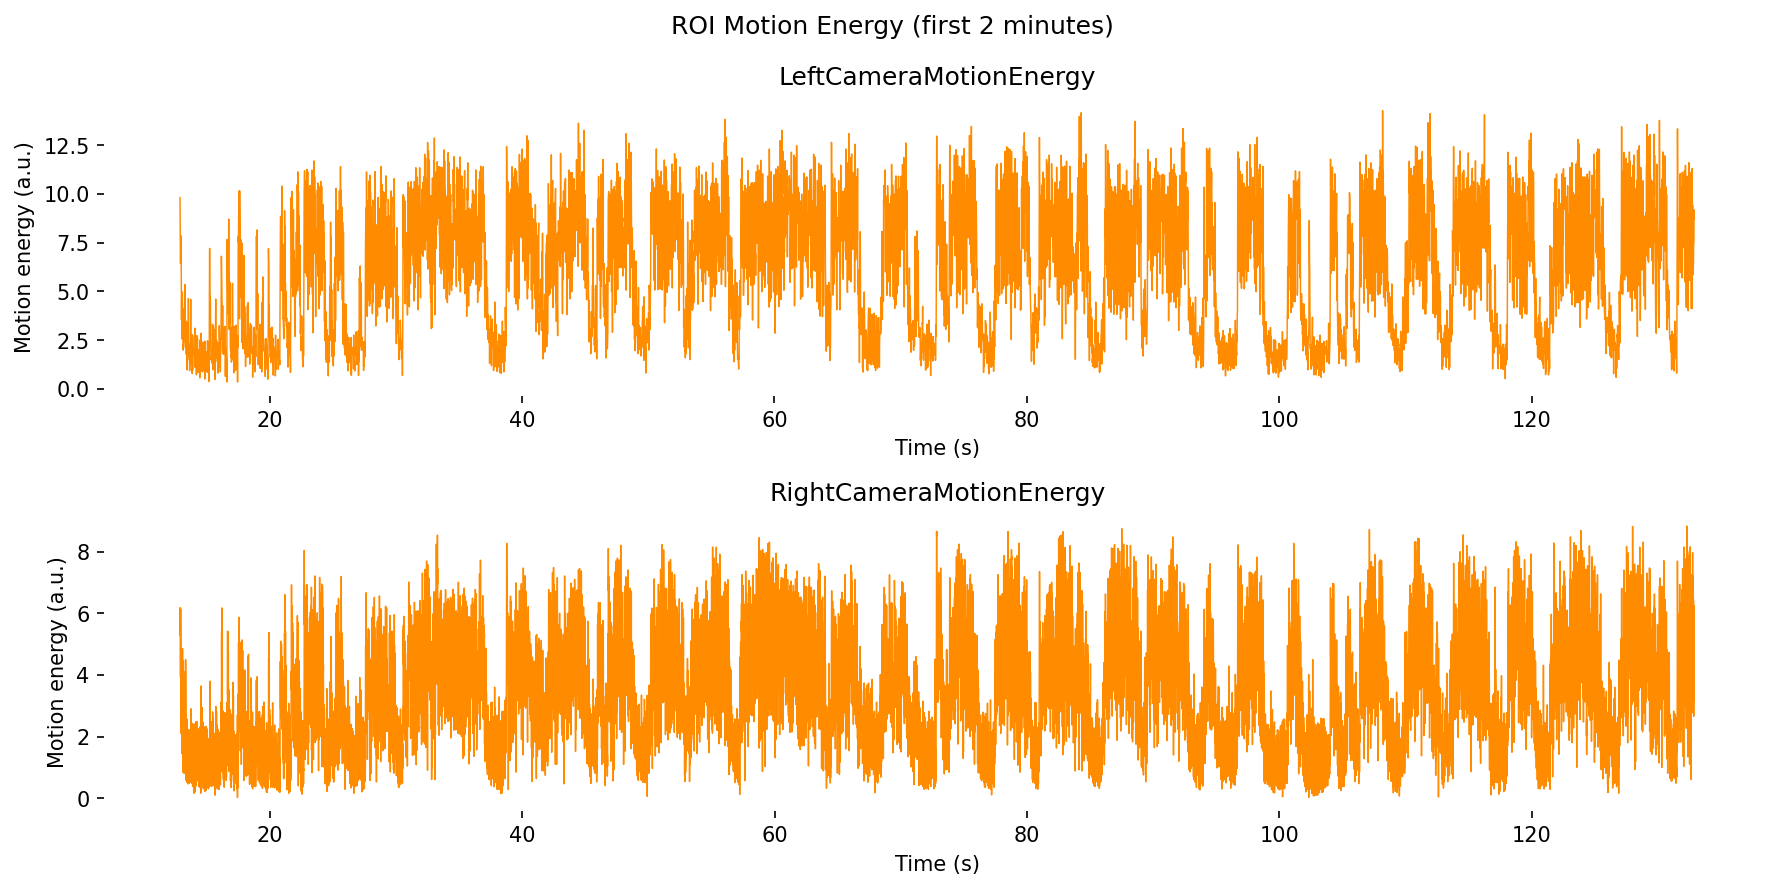

In [12]:
# --- Plot motion energy for left and right cameras ---
me_names = [name for name in nwbfile.processing["motion_energy"].keys() if "MotionEnergy" in name]

fig, axes = plt.subplots(len(me_names), 1, figsize=(12, 3 * len(me_names)), dpi=150, squeeze=False, sharex=False)

for ax, name in zip(axes[:, 0], me_names):
    ts = nwbfile.processing["motion_energy"][name]
    t = ts.timestamps[:]
    window_mask = (t >= t[0]) & (t <= t[0] + 120.0)
    ax.plot(t[window_mask], ts.data[window_mask], color='darkorange', linewidth=0.7)
    ax.set_title(name)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Motion energy (a.u.)')
    ax.set_frame_on(False)

plt.suptitle('ROI Motion Energy (first 2 minutes)', fontsize=12)
plt.tight_layout()
plt.show()

---

# 8. Wheel motion <a id="wheel"></a>

The steering wheel is the primary behavioral input device. The mouse rotates it to report
perceptual decisions during the task. Wheel data is stored as:

| Name | Description |
|---|---|
| `WheelPositionSeries` | Absolute unwrapped angle from session start (rad) |
| `WheelVelocity` | Angular velocity filtered at 1000 Hz (rad/s) |
| `WheelAcceleration` | Angular acceleration (rad/s2) |
| `WheelMovementIntervals` | Onset/offset of detected movement bouts |

In [13]:
print("=== WHEEL PROCESSING MODULE ===\n")
wheel_series = []
for name, proc in nwbfile.processing["wheel"].items():
    print("-" * 100)
    print(f"{name}  ")
    print(f"   Description: {proc.description}")
    if "Intervals" in name:
        display(proc.to_dataframe().head(5))  # Display first 5 rows
    else:
        wheel_series.append(name)
    print("-" * 100)

=== WHEEL PROCESSING MODULE ===

----------------------------------------------------------------------------------------------------
WheelAccelerationSmoothed  
   Description: Wheel angular acceleration derived from velocity (WheelVelocitySmoothed). Computed as the second derivative of the smoothed position signal.
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
WheelPosition  
   Description: Absolute unwrapped wheel angle recorded from a quadrature rotary encoder. The wheel (diameter 6.2 cm) is positioned under the mouse's forepaws and serves as the primary behavioral input device for reporting perceptual decisions. Sampling is event-driven: timestamps are recorded only when the wheel moves (i.e., when the encoder generates TTL edges), resulting in irregular inter-sample intervals. The encoder uses X4 decoding of two 90-degree pha

,start_time,stop_time,peak_amplitude
id,,,
0,17.569,17.719,-0.019558
1,20.851,21.015,-0.013635
2,21.726,21.858,-0.011853
3,22.091,22.213,-0.021135
4,22.981,24.308,0.336964


----------------------------------------------------------------------------------------------------


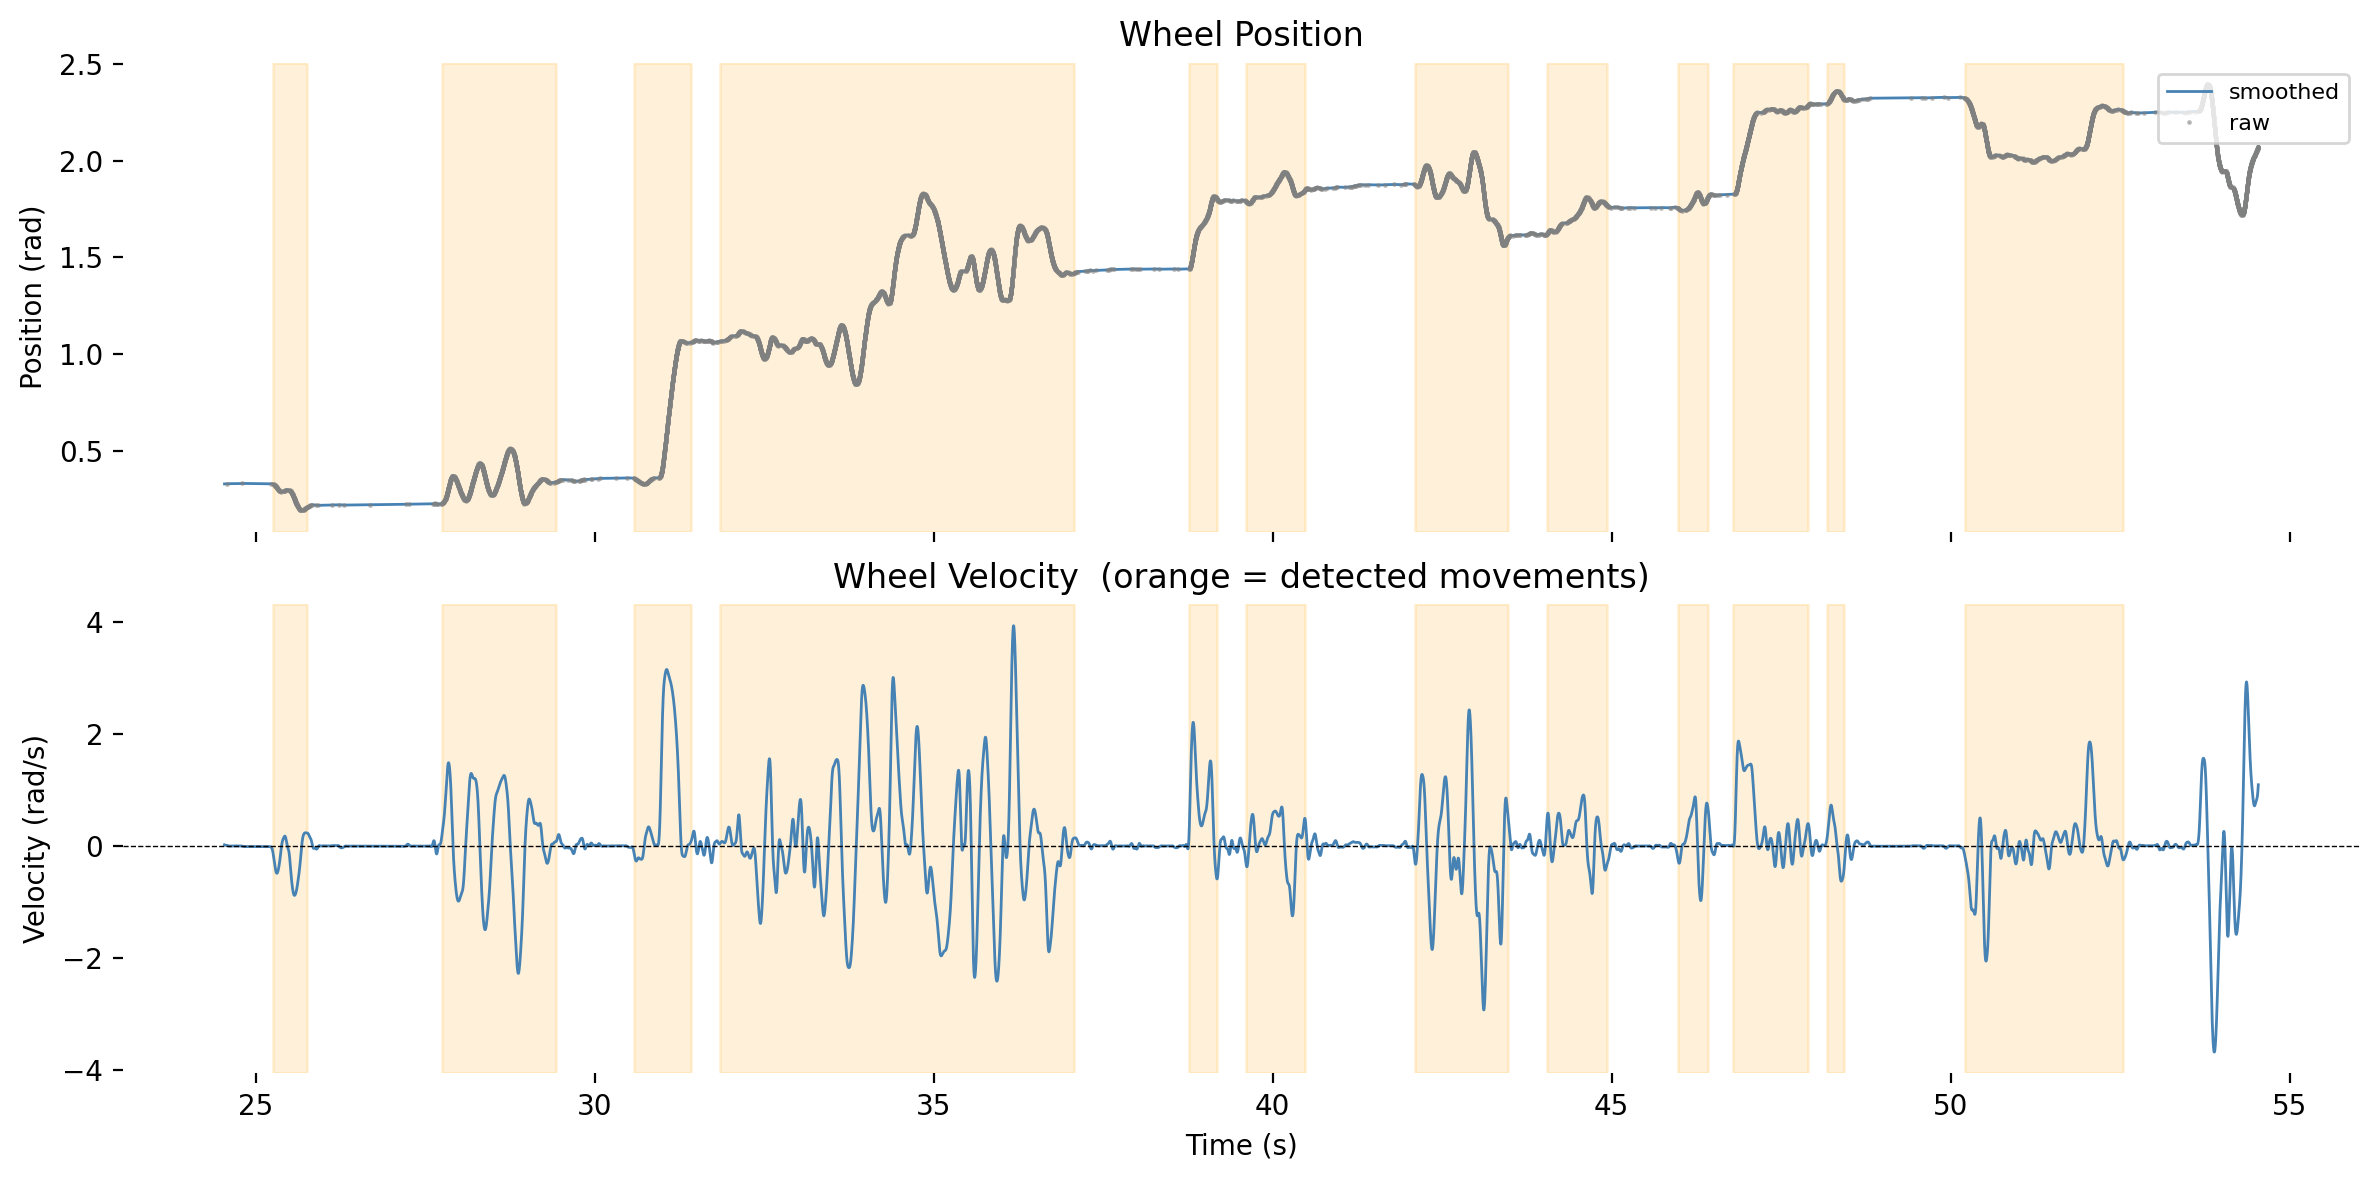

In [14]:
wheel_module = nwbfile.processing["wheel"]

# Load smoothed position and velocity (1000 Hz uniform grid, stored with rate+starting_time)
pos_smooth = wheel_module["WheelPositionSmoothed"]
vel_smooth = wheel_module["WheelVelocitySmoothed"]
movements = wheel_module["WheelMovementIntervals"]

# Reconstruct timestamps for rate-based series
n_smooth = pos_smooth.data.shape[0]
t_smooth = pos_smooth.starting_time + np.arange(n_smooth) / pos_smooth.rate
p_smooth = pos_smooth.data[:]
v_smooth = vel_smooth.data[:]

# Raw position uses irregular timestamps (event-driven encoder edges)
pos_raw = wheel_module["WheelPosition"]
t_raw = pos_raw.timestamps[:]
p_raw = pos_raw.data[:]

# Show a 30-second window starting just before the first trial
trial_start = float(nwbfile.trials["start_time"][0])
t_win_start = trial_start - 2.0
t_win_end = trial_start + 28.0

smooth_mask = (t_smooth >= t_win_start) & (t_smooth <= t_win_end)
raw_mask = (t_raw >= t_win_start) & (t_raw <= t_win_end)

# Movement intervals in window
mov_df = movements.to_dataframe()
mov_in_win = mov_df[(mov_df["start_time"] >= t_win_start) & (mov_df["stop_time"] <= t_win_end)]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=200, sharex=True)

# --- Top: wheel position ---
axes[0].plot(t_smooth[smooth_mask], p_smooth[smooth_mask], color="steelblue", linewidth=1.0, label="smoothed")
axes[0].plot(t_raw[raw_mask], p_raw[raw_mask], ".", color="gray", markersize=1.5, alpha=0.5, label="raw")
for _, row in mov_in_win.iterrows():
    axes[0].axvspan(row["start_time"], row["stop_time"], alpha=0.15, color="orange")
axes[0].set_ylabel("Position (rad)")
axes[0].set_title("Wheel Position")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_frame_on(False)

# --- Bottom: smoothed velocity with movement intervals ---
axes[1].plot(t_smooth[smooth_mask], v_smooth[smooth_mask], color="steelblue", linewidth=1.0)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
for _, row in mov_in_win.iterrows():
    axes[1].axvspan(row["start_time"], row["stop_time"], alpha=0.15, color="orange")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Velocity (rad/s)")
axes[1].set_title("Wheel Velocity  (orange = detected movements)")
axes[1].set_frame_on(False)

plt.tight_layout()
plt.show()